In [46]:
"""
IDW Hourly Spatial Gridded Interpolation with Elevation Adjustment

Generate hourly 1-km predictor grids (temperature, humidity, PLP, MRoS proxy) using inverse-distance weighting (IDW) 
with elevation correction via dynamic lapse-rate detrending and retrending. 
Method aligns with PRISM, Daymet, and WorldClim topographic adjustments.


1. Grid Setup
grid_centers()
Data: `dem1k_profile`, `dem1k_data`, `grid_xy`, `grid_elev`, `proj_crs`
• Load 1-km projected DEM (DEM_1km.tif) using rasterio.
• Make sure DEM is reprojected into the m scale, cannot be in degrees when performing IDW!!
• Compute grid centers (`grid_xy`) and flatten DEM elevations (`grid_elev`).
• Store CRS and transform metadata for interpolation and output alignment.

2. Inputs
• `st_hr`   → hourly station data (lon, lat, elev, temp_air, temp_dew, temp_wet, rh)
• `imerg_hr` → hourly IMERG PLP samples
• `mros_hr`  → hourly MRoS proxy PLP points (rain=100, mix=50, snow=0)
• Fill missing station elevations using DEM via `add_dem_elev_if_missing()`.

3. Hourly Interpolation Loop
estimate_lapse_rate(), idw_detrend_by_lapse()
• Subset station, IMERG, and MRoS data for each hour.
• Estimate dynamic lapse rate (°C/m) from `temp_air ~ elev` (OLS fit):
  - Bounds slope to -0.009 … -0.003 °C/m; fallback = CONFIG["lapse_degC_per_m"].
• Apply this lapse to temperature variables; set lapse=0 for others.

4. IDW with Elevational Adjustment
idw_detrend_by_lapse() ------- PRISM-style approach
Steps:
1. Project station coords (lon, lat) → DEM CRS.
2. Detrend: remove lapse term (`v_norm = v - γ*z_station`).
3. 2-D IDW interpolation (KDTree; k-nearest; power=2).
4. Retrend: reapply lapse (`v_final = v_interp + γ*z_grid`).
Result:
• Elevation incorporated physically (via lapse) rather than geometrically (3D distance).
• Produces smooth, topographically consistent fields.

5. Variables
variables = ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy", "plp"]
• `temp_air`, `temp_dew`, `temp_wet` → use dynamic lapse each hour.
• `rh`, `mros_plp_proxy`, `plp` → same IDW geometry, lapse=0.
• Ensures all predictors share identical spatial structure.

6. Outputs
• Assemble hourly grids into `xarray.Dataset` with dims (time, y, x).
• Add DEM elevation layer and CRS metadata (`spatial_ref`, `GeoTransform`).
• Save as compressed CF-compliant NetCDF (`hourly_predictors_1km.nc`).

• Dynamic lapse-rate detrending/retrending integrates elevation consistently.
• 2-D IDW avoids unstable 3-D geometry.
• Uniform interpolation ensures spatial alignment across all predictors.



Notes:
- two biggest levers are min points and k/weights.
- future considerations:
-- terrain facet awareness: lee-side smearing, limit neighbors across major ridgelines or give anisotropic weights
"""


# Dependencies: pandas, numpy, pyarrow, geopandas, shapely, rasterio, rioxarray, xarray,
#               pyproj, scipy (KDTree), tqdm

import re
import json
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import rasterio as rio
from rasterio.warp import transform_bounds, reproject, Resampling, calculate_default_transform
import xarray as xr
import rioxarray  # noqa: F401 (registers .rio accessor)
from pyproj import CRS, Transformer
from scipy.spatial import cKDTree
from tqdm import tqdm
import pytz
from collections import defaultdict
import math
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import netCDF4
from sklearn.linear_model import LinearRegression
from rasterio.transform import rowcol as rio_rowcol
from pyproj import Transformer


# Path setups

In [47]:
# --------------------------- CONFIG ---------------------------------
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

CONFIG = {
    "wy_start": "2024-10-01T00:00:00Z",
    "wy_end":   "2025-05-31T23:59:59Z",
    "test_start": "2025-03-30T00:00:00Z",   # narrow test window first
    "test_end":   "2025-04-02T23:00:00Z",
    # "test_start": "2024-10-01T00:00:00Z",   # Entire window
    # "test_end":   "2025-05-31T23:59:59Z",

    # "dem_path":  BASE_DIR / "DEM_1km.tif", 
    "dem_path":  BASE_DIR / "DEM_1km_clipped_v2.tif",  # 10/29/25: using clipped DEM now (smaller extent)
    "out_dir":  BASE_DIR / "outputs/hourly_pipeline",

    # ---- Interpolation parameters ----
    "idw_power": 2.0,
    "k_nearest": 8,

    # ---- Minimum points ----
    # Baseline global minimum (used if variable not listed in VAR_CONFIG)
    "min_points_global": 3,
    # Minimum stations required to estimate dynamic lapse rate
    "min_points_lapse": 5,

    # ---- Lapse-rate defaults ----
    # Fallback lapse rate (°C per meter; i.e., -5 °C per km)
    "lapse_degC_per_m": -0.005,

    # ---- Projection ----
    "proj_fallback": "EPSG:26911",   # NAD83 / UTM zone 11N (units: meters)
}

# ---------------- Variable-specific interpolation settings ----------------
VAR_CONFIG = {
    "temp_air":       {"min_points": 4, "apply_lapse": True},
    "temp_dew":       {"min_points": 4, "apply_lapse": True},
    "temp_wet":       {"min_points": 4, "apply_lapse": True},
    "rh":             {"min_points": 4, "apply_lapse": False},
    "mros_plp_proxy": {"min_points": 2, "apply_lapse": False},
    "plp":            {"min_points": 1, "apply_lapse": False},
}

# Optional global safety minimum
MIN_POINTS_GLOBAL = CONFIG["min_points_global"]

out_dir = Path(CONFIG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype


In [48]:
# ------------------------- Utility functions for time --------------------------------
def to_utc(dt_series: pd.Series) -> pd.DatetimeIndex:
    """Force timestamps to UTC, making naive → UTC-naive assumed in UTC."""
    dt = pd.to_datetime(dt_series, errors="coerce", utc=True)
    # If dt_series had naive datetimes and pandas assumed local, .tz_convert('UTC') not needed.
    return dt

def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso),
                         freq="H", tz="UTC")

def print_time(ts):
    return pd.to_datetime(ts).strftime("%Y-%m-%d %H:%MZ")

In [49]:
# --------------------- Load DEM ------------------------

# Computes the projected x,y coordinates (in meters) for every pixel center in the DEM
def grid_centers(profile):
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

# Load DEM, reproject if CRS is geographic/in degrees (EPSG:4326)
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

with rio.open(CONFIG["dem_path"]) as src:
    dem_crs = src.crs
    if not dem_crs or not dem_crs.is_projected:
        print(f"DEM is geographic ({dem_crs}); reprojecting to {CONFIG['proj_fallback']} ...")
        dst_crs = CONFIG["proj_fallback"]
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
        dem1k_data = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rio.band(src, 1),
            destination=dem1k_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        dem1k_profile = kwargs
        proj_crs = dst_crs
    else:
        dem1k_profile = src.profile
        dem1k_data = src.read(1)
        proj_crs = dem_crs

grid_xy = grid_centers(dem1k_profile)
grid_elev = dem1k_data.ravel()

print(f"DEM CRS: {proj_crs}, pixel size: {abs(dem1k_profile['transform'].a):.2f} m")


DEM is geographic (EPSG:4326); reprojecting to EPSG:26911 ...
DEM CRS: EPSG:26911, pixel size: 961.82 m


In [50]:
# # Save reprojected DEM as new GeoTIFF ---
# out_reproj = BASE_DIR / "DEM_1km_clipped_v2_rpj.tif"
# kwargs.update(dtype=rasterio.float32, count=1, compress="lzw")

# with rasterio.open(out_reproj, "w", **kwargs) as dst:
#     dst.write(dem1k_data, 1)

# print(f"Saved reprojected DEM to: {out_reproj}")


DEM CRS: EPSG:26911, resolution: 961.82 m
DEM bounds: BoundingBox(left=162846.25611536083, bottom=4175439.7352327444, right=303272.0413756766, top=4425513.051449745)


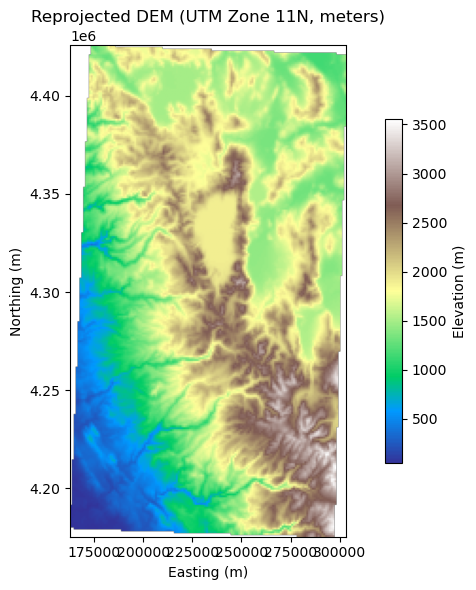

In [51]:
dem_path = BASE_DIR / "DEM_1km_clipped_v2_rpj.tif"

with rasterio.open(dem_path) as src:
    dem = src.read(1)
    transform = src.transform
    crs = src.crs
    bounds = src.bounds
    res = abs(transform.a)
    print(f"DEM CRS: {crs}, resolution: {res:.2f} m")
    print(f"DEM bounds: {bounds}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate extent for correct orientation
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

im = ax.imshow(
    dem,
    cmap="terrain",
    extent=extent,
    origin="upper",   # ensures DEM isn’t flipped vertically
)
ax.set_title("Reprojected DEM (UTM Zone 11N, meters)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
fig.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)

plt.tight_layout()
plt.show()


In [52]:
print("DEM path:", CONFIG["dem_path"])
print("DEM width × height:", dem1k_profile["width"], dem1k_profile["height"])
print("DEM transform:", dem1k_profile["transform"])
print("DEM bounds:", rio.transform.array_bounds(
    dem1k_profile["height"], dem1k_profile["width"], dem1k_profile["transform"]))


DEM path: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\DEM_1km_clipped_v2.tif
DEM width × height: 146 260
DEM transform: | 961.82, 0.00, 162846.26|
| 0.00,-961.82, 4425513.05|
| 0.00, 0.00, 1.00|
DEM bounds: (162846.25611536083, 4175439.7352327444, 303272.0413756766, 4425513.051449745)


In [53]:
# -------------- Load datasets from pre-processing step ----------------------

st_hr   = pd.read_parquet(out_dir / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(out_dir / "hourly_data/imerg_hourly.parquet")
mros_hr     = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

In [54]:
# -------------------- Filter data to AOI -------------------------------------

def load_dem_and_aoi(dem_path: str):
    with rio.open(dem_path) as src:
        dem_crs = CRS.from_wkt(src.crs.to_wkt()) if src.crs else None
        bounds = src.bounds
        aoi_wgs84 = transform_bounds(src.crs, "EPSG:4326",
                                     bounds.left, bounds.bottom, bounds.right, bounds.top,
                                     densify_pts=21)
    aoi_poly = box(aoi_wgs84[0], aoi_wgs84[1], aoi_wgs84[2], aoi_wgs84[3])
    return dem_path, dem_crs, aoi_poly

dem_path, dem_crs, aoi_poly = load_dem_and_aoi(CONFIG["dem_path"])

def filter_points_to_aoi(df: pd.DataFrame, aoi_poly) -> pd.DataFrame:
    g = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
    poly = gpd.GeoSeries([aoi_poly], crs="EPSG:4326").iloc[0]
    mask = g.intersects(poly)
    return df.loc[mask.values].drop(columns=["geometry"], errors="ignore")

st_hr   = filter_points_to_aoi(st_hr, aoi_poly)
imerg_hr= filter_points_to_aoi(imerg_hr, aoi_poly)
mros_hr    = filter_points_to_aoi(mros_hr, aoi_poly)

print(len(st_hr), len(imerg_hr), len(mros_hr))

313521 1702800 7367


In [55]:
# -------------------- IDW Functions ------------------------------------
def build_transformer(src_epsg: str, dst_crs):
    return Transformer.from_crs(src_epsg, dst_crs, always_xy=True)

def idw_detrend_by_lapse(
    hour_points: pd.DataFrame,
    grid_xy: np.ndarray,
    grid_elev: np.ndarray,
    proj_crs,
    value_col: str = "temp_air",
    station_elev_col: str = "elev",
    lapse_degC_per_m: float = -0.005,
    idw_power: float = 2.0,
    k: int = 8,
    min_points: int = 3
) -> np.ndarray:
    """
    Perform inverse-distance weighted interpolation with lapse rate.

    Steps:
      1. Project station coordinates to DEM CRS.
      2. Detrend station values to sea level (remove lapse*z_station).
      3. IDW interpolate detrended values (residuals).
      4. Add back the lapse*z_grid trend at each DEM cell.

    Returns
    np.ndarray
        Flattened array of interpolated values (float32) with NaN where insufficient data.
    """
    # Filter valid points
    pts = hour_points.dropna(subset=[value_col, "lon", "lat", station_elev_col])
    if pts.empty or pts[value_col].notna().sum() < min_points:
        return np.full(grid_elev.shape, np.nan, dtype=np.float32)

    # Project station coordinates to DEM CRS ( in m!!)
    tf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    px, py = tf.transform(pts["lon"].values, pts["lat"].values)
    P = np.column_stack([px, py])

    vj = pts[value_col].values.astype(float)
    zj = pts[station_elev_col].values.astype(float)

    # --- 1. Detrend: normalize each station to reference elevation (sea level)
    #     v_norm = vj - lapse * zj
    v_norm = vj - lapse_degC_per_m * zj

    # --- 2. Build KDTree and query k nearest neighbors per grid point
    tree = cKDTree(P)
    dists, idxs = tree.query(grid_xy, k=min(k, len(P)))

    if dists.ndim == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]

    # --- 3. Compute IDW weights
    with np.errstate(divide="ignore"):
        w = 1.0 / np.power(dists, idw_power)
    w[np.isinf(w)] = 1e12
    w[~np.isfinite(w)] = 0.0
    w_sum = w.sum(axis=1, keepdims=True)
    w_norm = np.divide(w, w_sum, out=np.zeros_like(w), where=w_sum > 0)

    valid_counts = np.sum(w > 0, axis=1)
    v_interp_norm = np.sum(w_norm * v_norm[idxs], axis=1)
    v_interp_norm[valid_counts < min_points] = np.nan

    # --- 4. Reapply trend to grid elevation
    v_final = v_interp_norm + lapse_degC_per_m * grid_elev

    return v_final.astype(np.float32)



In [56]:
# ------------- Functions: per-hour lapse + DEM elevation sampling -----------------

def estimate_lapse_rate(
    st_df: pd.DataFrame,
    temp_col: str = "temp_air",
    elev_col: str = "elev",
    default_lapse: float = -0.005,
    min_points: int = 5,
    bounds: tuple = (-0.009, 0.002)
) -> float:
    """
    Dynamically estimate lapse rate (°C per meter) from station data.
    """
    use = st_df.dropna(subset=[temp_col, elev_col])
    if len(use) < min_points:
        return default_lapse

    X = use[[elev_col]].values.astype(float)
    y = use[temp_col].values.astype(float)

    try:
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
        if bounds[0] <= slope <= bounds[1]:
            return slope
        else:
            return default_lapse
    except Exception:
        return default_lapse


def add_dem_elev_if_missing(st_df: pd.DataFrame,
                            profile, proj_crs) -> pd.DataFrame:
    """
    Ensure stations have 'elev' using the 1-km DEM grid if missing.
    Nearest-neighbor sample from dem1k_data/profile given lon/lat.
    """
    if "elev" not in st_df.columns:
        st_df = st_df.copy()
        st_df["elev"] = np.nan

    need = st_df["elev"].isna()
    if not need.any():
        return st_df

    # project lon/lat -> DEM CRS
    tf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    xx, yy = tf.transform(st_df.loc[need, "lon"].values, st_df.loc[need, "lat"].values)

    # row/col in DEM grid
    rr, cc = rio_rowcol(profile["transform"], xx, yy, op=round)
    # clip to grid
    rr = np.clip(rr, 0, profile["height"] - 1)
    cc = np.clip(cc, 0, profile["width"]  - 1)

    # sample nearest from dem1k_data
    st_df = st_df.copy()
    st_df.loc[need, "elev"] = dem1k_data[rr, cc]
    return st_df


In [57]:
# -------------------- IDW Gridding Implementation ------------------------------------

hours = hourly_index(CONFIG["test_start"], CONFIG["test_end"])

variables = [
    "temp_air",
    "temp_dew",
    "temp_wet",
    "rh",
    "mros_plp_proxy",
    "plp",
]

# Build coordinates from DEM profile
from rasterio.transform import xy as rio_xy
H, W = dem1k_profile["height"], dem1k_profile["width"]
T = dem1k_profile["transform"]

rows = np.arange(H)
cols = np.arange(W)
x_centers = np.array([rio_xy(T, 0, c, offset="center")[0] for c in cols])
y_centers = np.array([rio_xy(T, r, 0, offset="center")[1] for r in rows])

coords = {"time": hours, "y": y_centers, "x": x_centers}
data_vars = {name: np.full((len(hours), H, W), np.nan, dtype=np.float32) for name in variables}

for ti, t in enumerate(tqdm(hours, desc="Hourly surfaces", ncols=88)):
    st_t   = st_hr[st_hr["hour_utc"] == t]
    mros_t = mros_hr[mros_hr["hour_utc"] == t]
    imerg_t= imerg_hr[imerg_hr["hour_utc"] == t]

    print(f"\n[{print_time(t)}] Processing interpolation...")
    st_t = add_dem_elev_if_missing(st_t, dem1k_profile, proj_crs)

    # Dynamic lapse from station air temperature
    lapse_now = estimate_lapse_rate(
        st_t, temp_col="temp_air", default_lapse=CONFIG["lapse_degC_per_m"]
    )
    print(f"  Dynamic lapse = {lapse_now:.4f} °C/m")

    for name in tqdm(variables, desc=f"  vars {print_time(t)}", leave=False, ncols=88):
        # Select source and prepare dataframe
        if name in ["temp_air", "temp_dew", "temp_wet", "rh"]:
            pts = st_t[["lon", "lat", "elev", name]].dropna(subset=[name])
        elif name == "mros_plp_proxy":
            pts = mros_t.rename(columns={"mros_plp_proxy": name})[["lon", "lat", name]].assign(elev=0.0)
        elif name == "plp":
            pts = imerg_t.rename(columns={"plp": name})[["lon", "lat", name]].assign(elev=0.0)
        else:
            continue

        # Variable-specific settings
        vcfg = VAR_CONFIG.get(name, {"min_points": MIN_POINTS_GLOBAL, "apply_lapse": False})
        min_pts = vcfg.get("min_points", MIN_POINTS_GLOBAL)
        lapse_apply = lapse_now if vcfg["apply_lapse"] else 0.0
        print(f"    {name}: {n_valid} valid points, required min_pts={min_pts}")


        # Skip if insufficient data
        n_valid = pts[name].notna().sum()
        if n_valid < min_pts:
            print(f"    Skipping {name} — insufficient data ({n_valid} valid pts, need {min_pts})")
            continue

        # Perform IDW detrend/retrend interpolation
        vals = idw_detrend_by_lapse(
            hour_points=pts,
            grid_xy=grid_xy,
            grid_elev=grid_elev,
            proj_crs=proj_crs,
            value_col=name,
            station_elev_col="elev",
            lapse_degC_per_m=lapse_apply,
            idw_power=CONFIG["idw_power"],
            k=CONFIG["k_nearest"],
            min_points=min_pts
        )

        data_vars[name][ti, :, :] = vals.reshape(H, W)



# assemble dataset
ds = xr.Dataset(
    {
        **{k: xr.DataArray(v, coords=coords, dims=("time","y","x"))
           for k, v in data_vars.items()},
        "elev": xr.DataArray(
            dem1k_data.astype(np.float32),
            coords={"y": y_centers, "x": x_centers},
            dims=("y","x"),
        ),
    },
    attrs={
        "title": "Hourly predictor stacks on 1-km grid",
        "lapse_degC_per_m": CONFIG["lapse_degC_per_m"],
        "idw_power": CONFIG["idw_power"],
        "k_nearest": CONFIG["k_nearest"],
    }
)

# Coordinate metadata (meters)
ds["x"].attrs.update({
    "units": "m",
    "standard_name": "projection_x_coordinate",
    "long_name": "x coordinate of projection",
})
ds["y"].attrs.update({
    "units": "m",
    "standard_name": "projection_y_coordinate",
    "long_name": "y coordinate of projection",
})

# Make geospatial and CF-compliant
ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
ds = ds.rio.write_crs(dem1k_profile["crs"], grid_mapping_name="spatial_ref")
ds = ds.rio.write_transform(dem1k_profile["transform"])

# Ensure each data variable points to the grid mapping
for v in ds.data_vars:
    ds[v].attrs["grid_mapping"] = "spatial_ref"

# Add a geotransform
A = dem1k_profile["transform"]
ds.attrs["GeoTransform"] = f"{A.c} {A.a} {A.b} {A.f} {A.d} {A.e}"

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2657028924.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso),
Hourly surfaces:   0%|                                           | 0/96 [00:00<?, ?it/s]


[2025-03-30 00:00Z] Processing interpolation...
  Dynamic lapse = -0.0037 °C/m


    temp_air: 330 valid points, required min_pts=4


    temp_dew: 40 valid points, required min_pts=4


    temp_wet: 40 valid points, required min_pts=4
    rh: 40 valid points, required min_pts=4


...


[2025-04-02 23:00Z] Processing interpolation...
  Dynamic lapse = -0.0051 °C/m


    temp_air: 330 valid points, required min_pts=4
    temp_dew: 40 valid points, required min_pts=4


    temp_wet: 40 valid points, required min_pts=4
    rh: 40 valid points, required min_pts=4


    mros_plp_proxy: 40 valid points, required min_pts=2
    Skipping mros_plp_proxy — insufficient data (1 valid pts, need 2)
    plp: 1 valid points, required min_pts=1


Hourly surfaces: 100%|██████████████████████████████████| 96/96 [00:38<00:00,  2.50it/s]


In [58]:
# -------------------- Save NetCDFs ------------------------------------

out_nc = out_dir / "hourly_predictors_1km_IDW_v3.nc"

# Ensure time is tz-naive
if hasattr(ds.indexes["time"], "tz") and ds.indexes["time"].tz is not None:
    ds = ds.assign_coords(time=ds.indexes["time"].tz_localize(None))

# Reassert spatial metadata (idempotent & safe)
ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
ds = ds.rio.write_crs(dem1k_profile["crs"])               # use DEM CRS object
ds = ds.rio.write_transform(dem1k_profile["transform"])   # use DEM affine

# CF link each data var to the grid mapping (spatial_ref)
for v in ds.data_vars:
    ds[v].attrs.setdefault("grid_mapping", "spatial_ref")

# Build encoding per variable (match chunks to dims)
def _chunks_for(da):
    # cap chunk sizes to something sane
    if da.dims == ("time", "y", "x"):
        return (min(24, da.sizes["time"]),
                min(256, da.sizes["y"]),
                min(256, da.sizes["x"]))
    if da.dims == ("y", "x"):
        return (min(256, da.sizes["y"]),
                min(256, da.sizes["x"]))
    return None  # scalar or unusual dims

encoding = {}
for name, da in ds.data_vars.items():
    ch = _chunks_for(da)
    encoding[name] = ({"zlib": True, "complevel": 4, "chunksizes": ch}
                      if ch is not None else {"zlib": True, "complevel": 4} if da.ndim > 0 else {})

ds.to_netcdf(out_nc, engine="netcdf4", encoding=encoding)
print(f"Wrote {out_nc} using netCDF4 (compressed).")

print("DEM CRS:", proj_crs)
print("Station table sample (lon, lat):", st_hr[["lon", "lat"]].head().to_dict("records")[:2])



Wrote C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\hourly_predictors_1km_IDW_v3.nc using netCDF4 (compressed).
DEM CRS: EPSG:26911
Station table sample (lon, lat): [{'lon': -119.96, 'lat': 38.68}, {'lon': -119.96, 'lat': 38.68}]


In [59]:
# # Check netcdf
# from netCDF4 import Dataset

# nc = Dataset(out_nc, mode="r")

# # Dimensions
# print("\nDimensions:")
# for name, dim in nc.dimensions.items():
#     print(f"  {name}: {len(dim)}")

# # Variables
# print("\nVariables:")
# for name, var in nc.variables.items():
#     print(f"  {name}: shape={var.shape}, dtype={var.dtype}, attrs={ {k: v for k, v in var.__dict__.items()} }")

# # Check the data
# ds = xr.open_dataset(out_nc)

# # Print a quick summary again
# print(ds)

# # Inspect first few timesteps for one variable (e.g. temp_air)
# print("\nFirst 2 timesteps of temp_air, temp_wet, temp_dew, rh, mros_plp_proxy, plp: at 5x5 corner:")
# print(ds["temp_air"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)
# print(ds["temp_wet"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)
# print(ds["temp_dew"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)
# print(ds["rh"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)
# print(ds["mros_plp_proxy"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)
# print(ds["plp"].isel(time=slice(0,10), y=slice(0,5), x=slice(0,5)).values)

# ds.close()


In [60]:
# -------------------- Quick Plotting ------------------------------------

from pyproj import CRS

def quicklook_hour(
    ds, t, st_t, mros_t, out_png,
    vars_to_show=("plp","mros_plp_proxy","temp_air","temp_dew","temp_wet","rh")
):
    # match time index
    times_ds = pd.to_datetime(ds.time.values).floor("h")
    t_floor  = pd.to_datetime(t).floor("h")
    if t_floor not in times_ds.values:
        print(f"No matching time {t_floor} in dataset for quicklook.")
        return
    ti = int(np.where(times_ds == t_floor)[0][0])

    # axes extent (xmin, xmax, ymin, ymax)
    xvals = ds["x"].values
    yvals = ds["y"].values
    xmin, xmax = float(np.min(xvals)), float(np.max(xvals))
    ymin, ymax = float(np.min(yvals)), float(np.max(yvals))
    extent = [xmin, xmax, ymin, ymax]

    keep = [v for v in vars_to_show if v in ds.data_vars]
    if not keep:
        print("No matching variables to plot.")
        return
    ncols, nrows = 3, int(np.ceil(len(keep)/3))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.8*nrows), squeeze=False)
    fig.suptitle(f"Quicklook @ {t_floor:%Y-%m-%d %H:%MZ}", fontsize=14)

    # dataset CRS (fallback to configured)
    target_crs = ds.rio.crs or CRS.from_user_input(CONFIG["proj_fallback"])
    tf = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)

    # --- project & CLIP stations ---
    st_x = np.empty(0)
    st_y = np.empty(0)
    if len(st_t):
        sx, sy = tf.transform(st_t["lon"].values, st_t["lat"].values)
        sx = np.asarray(sx); sy = np.asarray(sy)
        smask = (sx >= xmin) & (sx <= xmax) & (sy >= ymin) & (sy <= ymax) & np.isfinite(sx) & np.isfinite(sy)
        st_x, st_y = sx[smask], sy[smask]

    # --- project & CLIP MRoS ---
    mo_x = np.empty(0)
    mo_y = np.empty(0)
    if len(mros_t):
        mx, my = tf.transform(mros_t["lon"].values, mros_t["lat"].values)
        mx = np.asarray(mx); my = np.asarray(my)
        mmask = (mx >= xmin) & (mx <= xmax) & (my >= ymin) & (my <= ymax) & np.isfinite(mx) & np.isfinite(my)
        mo_x, mo_y = mx[mmask], my[mmask]

    for i, var in enumerate(keep):
        ax = axes[i // ncols, i % ncols]
        arr = ds[var].isel(time=ti).values

        # color scaling
        if var in ("plp", "mros_plp_proxy", "rh"):
            im = ax.imshow(arr, origin="upper", extent=extent, aspect="equal", vmin=0, vmax=100)
        else:
            im = ax.imshow(arr, origin="upper", extent=extent, aspect="equal")

        ax.set_title(var)
        ax.set_xlabel("Easting (km)")
        ax.set_ylabel("Northing (km)")
        ax.ticklabel_format(style="plain")   # disable 1e6 scientific format
        ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
        ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])

        # overlay
        if st_x.size:
            ax.scatter(st_x, st_y, s=15, c="white", edgecolor="k",
                    marker="o", linewidths=0.5, label="Stations", zorder=3)
        if mo_x.size:
            ax.scatter(mo_x, mo_y, s=25, c="red", edgecolor="k",
                    marker="^", linewidths=0.6, label="MRoS", zorder=3)

        ax.legend(loc="upper right", frameon=True, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    # turn off any leftover panels
    for j in range(len(keep), nrows*ncols):
        axes[j // ncols, j % ncols].axis("off")

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print(
        f"Saved quicklook: {out_png} | plotted {st_x.size} stations, {mo_x.size} MRoS (clipped to DEM)"
    )


# -------------------- Loop --------------------

quick_dir = Path(CONFIG["out_dir"]) / "maps"
quick_dir.mkdir(parents=True, exist_ok=True)

# day = "2025-03-04"
# all_times = pd.to_datetime(ds.time.values).floor("h")  # dataset times
# mask = all_times.normalize() == pd.to_datetime(day)
# sample_hours = all_times[mask]
sample_hours = pd.to_datetime(ds.time.values)[::max(1, len(ds.time)//20)]
# print(f"Found {len(sample_hours)} timesteps on {day}")

for t in sample_hours:
    t_floor = pd.to_datetime(t).floor("h")  # tz-naive

    # Ensure obs times are made tz-naive before comparison
    st_t   = st_hr[st_hr["hour_utc"].dt.tz_convert(None).dt.floor("h") == t_floor]
    mros_t = mros_hr[mros_hr["hour_utc"].dt.tz_convert(None).dt.floor("h") == t_floor]

    print(f"[{t_floor}] Stations: {len(st_t)}, MRoS: {len(mros_t)}")

    quicklook_hour(ds, t_floor, st_t, mros_t,
                   out_png=quick_dir / f"test3_IDW_quick_{print_time(t_floor).replace(':','-')}.png")


[2025-03-30 00:00:00] Stations: 40, MRoS: 0


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

Saved quicklook: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\maps\test3_IDW_quick_2025-03-30 00-00Z.png | plotted 40 stations, 0 MRoS (clipped to DEM)
[2025-03-30 04:00:00] Stations: 39, MRoS: 0


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

Saved quicklook: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\maps\test3_IDW_quick_2025-03-30 04-00Z.png | plotted 39 stations, 0 MRoS (clipped to DEM)
[2025-03-30 08:00:00] Stations: 40, MRoS: 0


...

Saved quicklook: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\maps\test3_IDW_quick_2025-04-02 12-00Z.png | plotted 40 stations, 1 MRoS (clipped to DEM)
[2025-04-02 16:00:00] Stations: 40, MRoS: 0


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

Saved quicklook: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\maps\test3_IDW_quick_2025-04-02 16-00Z.png | plotted 40 stations, 0 MRoS (clipped to DEM)
[2025-04-02 20:00:00] Stations: 40, MRoS: 5


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_49264\2826107130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

Saved quicklook: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\maps\test3_IDW_quick_2025-04-02 20-00Z.png | plotted 40 stations, 5 MRoS (clipped to DEM)
